## Imports

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.ensemble import BalancedRandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.ensemble import BalancedRandomForestClassifier

SEED = 42

## Feature Selection

In [6]:
#Paths
old_table_path = r"1.ALL_MorphoSPLUS_GalfitM_output_splus.csv"
labels_table_path = r"tabela_filtrada.csv"
new_table_path = r"campos_ML_1100.csv"

#Read

df_old_raw = pd.read_csv(old_table_path, low_memory=False)
df_labels = pd.read_csv(labels_table_path, low_memory=False)
df_new_raw = pd.read_csv(new_table_path, low_memory=False)

df_old_raw.columns = df_old_raw.columns.str.strip()
df_labels.columns = df_labels.columns.str.strip()
df_new_raw.columns = df_new_raw.columns.str.strip()

df_old_raw["ID_1"] = df_old_raw["ID_1"].astype(str).str.strip()
df_labels["ID"] = df_labels["ID"].astype(str).str.strip()

df_labels["label"] = df_labels["type"].apply(lambda x: 0 if int(x) == 0 else 1)

df_old = df_old_raw.merge(
    df_labels[["ID", "label"]],
    left_on="ID_1",
    right_on="ID",
    how="inner"
)

df_old["label"] = df_old["label"].astype(int)

print("Old table with labels:", df_old.shape)
print(df_old["label"].value_counts())

df_new = df_new_raw.copy()

df_new["label"] = pd.to_numeric(df_new["AstroInspectClass"], errors="coerce")

print("\nLabels in new table:")
print(df_new["label"].value_counts(dropna=False))

df_new = df_new.dropna(subset=["label"]).copy()
df_new["label"] = df_new["label"].astype(int)
df_new = df_new.drop(columns=["AstroInspectClass"])

print("\nNew table with labels:", df_new.shape)
print(df_new["label"].value_counts())

#Change the name of colums

rename_old_to_new = {
    "r_auto": "mag_auto_r",
    "g_auto": "mag_auto_g",
    "i_auto": "mag_auto_i",
    "z_auto": "mag_auto_z",
    "u_auto": "mag_auto_u",

    "J0378_auto": "mag_auto_j0378",
    "J0395_auto": "mag_auto_j0395",
    "J0410_auto": "mag_auto_j0410",
    "J0430_auto": "mag_auto_j0430",
    "J0515_auto": "mag_auto_j0515",
    "J0660_auto": "mag_auto_j0660",
    "J0861_auto": "mag_auto_j0861",

    "e_r_auto": "err_mag_auto_r",
    "e_g_auto": "err_mag_auto_g",
    "e_i_auto": "err_mag_auto_i",
    "e_z_auto": "err_mag_auto_z",
    "e_u_auto": "err_mag_auto_u",

    "e_J0378_auto": "err_mag_auto_j0378",
    "e_J0395_auto": "err_mag_auto_j0395",
    "e_J0410_auto": "err_mag_auto_j0410",
    "e_J0430_auto": "err_mag_auto_j0430",
    "e_J0515_auto": "err_mag_auto_j0515",
    "e_J0660_auto": "err_mag_auto_j0660",
    "e_J0861_auto": "err_mag_auto_j0861",

    "FLUX_RADIUS_50": "flux_radius_as_50_det",
    "FLUX_RADIUS_90": "flux_radius_as_90_det",

    "RA_2a": "ra",
    "DEC_2a": "dec",
    "Field": "field",

    "A": "a_image",
    "B": "b_image",
    "ELLIPTICITY": "ellipticity_det",
    "ELONGATION": "elongation_det",
    "THETA": "theta_det",
    "X": "x_pixel_det",
    "Y": "y_pixel_det",
    "ra_2": "input_RA",
    "dec_2": "input_DEC",
    "_dist_arcsec": "sep_arcsec",
}

df_old_aligned = df_old.copy()
df_old_aligned = df_old_aligned.rename(columns=rename_old_to_new)


df_old_aligned = df_old_aligned.loc[:, ~df_old_aligned.columns.duplicated()]
df_new = df_new.loc[:, ~df_new.columns.duplicated()]

#Convert to numeric

text_cols = [
    "source_folder", "source_file",
    "ID", "ID_1", "ID_2", "id_2", "ID4",
    "Field_ID", "field", "Field", "Dir_",
    "galaxy_id", "splus_id"
]

def convert_numeric_columns(df):
    df_conv = df.copy()

    for col in df_conv.columns:
        if col in text_cols or col == "label":
            continue

        s = df_conv[col].astype(str)
        s = s.str.replace("*", "", regex=False)
        s = s.str.replace(",", ".", regex=False)
        s = s.str.strip()
        s = s.replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan,
            "NaN": np.nan
        })

        df_conv[col] = pd.to_numeric(s, errors="coerce")

    return df_conv

df_old_num = convert_numeric_columns(df_old_aligned)
df_new_num = convert_numeric_columns(df_new)

#See different colums

num_old = set(df_old_num.select_dtypes(include=[np.number]).columns) - {"label"}
num_new = set(df_new_num.select_dtypes(include=[np.number]).columns) - {"label"}

common_numeric = sorted(num_old.intersection(num_new))
only_old = sorted(num_old - num_new)
only_new = sorted(num_new - num_old)


print("\n=== only old ===")
print(only_old)

print("\n=== only new ===")
print(only_new)

#Marge with numeric colums in commum

common_cols = common_numeric + ["label"]

df = pd.concat(
    [
        df_old_num[common_cols].copy(),
        df_new_num[common_cols].copy()
    ],
    ignore_index=True
)

df["label"] = df["label"].astype(int)

print("\nTabela final combinada:", df.shape)
print(df["label"].value_counts())

#Feature selection

numeric_cols = [c for c in df.columns if c != "label"]

features_all = [
    c for c in numeric_cols
    if df[c].notna().sum() >= 30 and df[c].nunique(dropna=True) >= 2
]

print("\nAll numeric colums:", len(features_all))

resultados = []

for col in features_all:
    temp = df[[col, "label"]].dropna()

    if temp.shape[0] < 200:
        continue

    if temp["label"].nunique() < 2:
        continue

    try:
        auc = roc_auc_score(temp["label"].values, temp[col].values)
        auc_sep = max(auc, 1 - auc)

        resultados.append([col, auc, auc_sep, temp.shape[0]])

    except Exception:
        pass

df_auc = pd.DataFrame(
    resultados,
    columns=["feature", "auc", "auc_separability", "n_valid"]
)

df_auc = df_auc.sort_values(
    "auc_separability",
    ascending=False
).reset_index(drop=True)

threshold_auc = 0.60

df_good = df_auc[df_auc["auc_separability"] > threshold_auc].copy()
df_good = df_good.reset_index(drop=True)

features_boas = df_good["feature"].tolist()
auc_dict = dict(zip(df_good["feature"], df_good["auc_separability"]))

print("\nFeatures with AUC separability > 0.60:", len(features_boas))

##remove with high correlation

threshold_corr = 0.90

if len(features_boas) > 1:
    corr_abs = df[features_boas].corr(method="pearson", min_periods=200).abs()
else:
    corr_abs = pd.DataFrame()

remover = set()

for i in range(len(features_boas)):
    for j in range(i + 1, len(features_boas)):

        f1 = features_boas[i]
        f2 = features_boas[j]

        if f1 in remover or f2 in remover:
            continue

        valor = corr_abs.loc[f1, f2]

        if np.isfinite(valor) and valor >= threshold_corr:

            if auc_dict[f1] >= auc_dict[f2]:
                remover.add(f2)
            else:
                remover.add(f1)

features_sel = [f for f in features_boas if f not in remover]

df_final = df_good[df_good["feature"].isin(features_sel)].copy()
df_final = df_final.sort_values(
    "auc_separability",
    ascending=False
).reset_index(drop=True)

print("\nFeatures removed by correlation:", len(remover))
print("Final features:", len(features_sel))

print("\nFeatures with AUC:")
print(df_final)

print("\nFinal features:")
print(features_sel)

Old table with labels: (1442, 220)
label
0    1251
1     191
Name: count, dtype: int64

Labels in new table:
label
0.0    1042
1.0      53
NaN       5
Name: count, dtype: int64

New table with labels: (1095, 442)
label
0    1042
1      53
Name: count, dtype: int64


C:\Users\anacs\AppData\Local\Temp\ipykernel_17448\3503121504.py:124: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.replace({
C:\Users\anacs\AppData\Local\Temp\ipykernel_17448\3503121504.py:124: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.replace({
C:\Users\anacs\AppData\Local\Temp\ipykernel_17448\3503121504.py:124: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the futu


=== only old ===
['Dir_', 'ID_gal', 'Norder_', 'Npix_', 'a_image', 'b_image']

=== only new ===
['EBV_SFD', 'ID4', 'M_g', 'M_i', 'M_r', 'M_u', 'class_star_det', 'err_mag_aper_3_g', 'err_mag_aper_3_i', 'err_mag_aper_3_j0378', 'err_mag_aper_3_j0395', 'err_mag_aper_3_j0410', 'err_mag_aper_3_j0430', 'err_mag_aper_3_j0515', 'err_mag_aper_3_j0660', 'err_mag_aper_3_j0861', 'err_mag_aper_3_r', 'err_mag_aper_3_u', 'err_mag_aper_3_z', 'err_mag_aper_6_g', 'err_mag_aper_6_i', 'err_mag_aper_6_j0378', 'err_mag_aper_6_j0395', 'err_mag_aper_6_j0410', 'err_mag_aper_6_j0430', 'err_mag_aper_6_j0515', 'err_mag_aper_6_j0660', 'err_mag_aper_6_j0861', 'err_mag_aper_6_r', 'err_mag_aper_6_u', 'err_mag_aper_6_z', 'err_mag_auto_restricted_g', 'err_mag_auto_restricted_i', 'err_mag_auto_restricted_j0378', 'err_mag_auto_restricted_j0395', 'err_mag_auto_restricted_j0410', 'err_mag_auto_restricted_j0430', 'err_mag_auto_restricted_j0515', 'err_mag_auto_restricted_j0660', 'err_mag_auto_restricted_j0861', 'err_mag_auto

## Remove features analysing the RF accuracy


Features used: 33
Features removed: 0
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8644
Precision Bad CV: 0.2772
Recall Bad CV: 0.8156
F1 Bad CV: 0.4137

Classification Report:
              precision    recall  f1-score   support

        Good       0.98      0.77      0.86      2293
         Bad       0.28      0.82      0.41       244

    accuracy                           0.78      2537
   macro avg       0.63      0.79      0.64      2537
weighted avg       0.91      0.78      0.82      2537



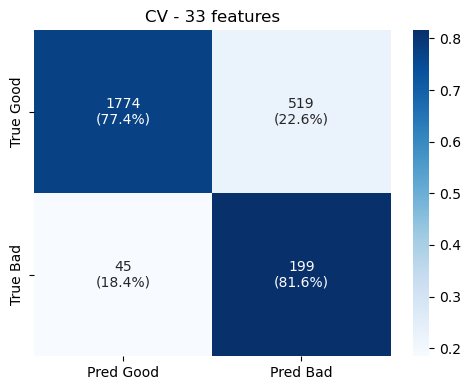


Features used: 32
Features removed: 1
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410']
Features removed:
['n_J0515']

AUC CV: 0.8574
Precision Bad CV: 0.2764
Recall Bad CV: 0.8033
F1 Bad CV: 0.4113

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.28      0.80      0.41       244

    accuracy                           0.78      2537
   macro avg       0.63      0.79      0.64      2537
weighted avg       0.91      0.78    

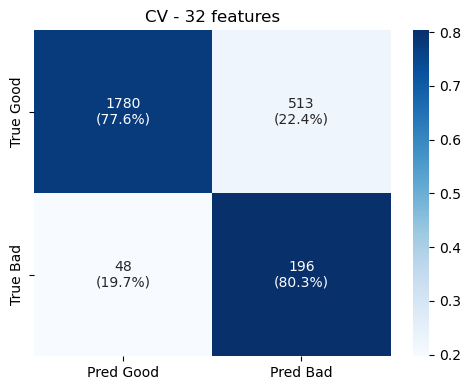


Features used: 31
Features removed: 2
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861']
Features removed:
['err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8566
Precision Bad CV: 0.2745
Recall Bad CV: 0.8033
F1 Bad CV: 0.4092

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.77      0.86      2293
         Bad       0.27      0.80      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.79      0.64      2537
weighted avg       0.91      0.78    

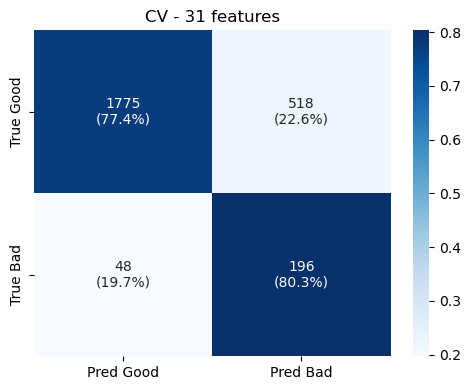


Features used: 30
Features removed: 3
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z']
Features removed:
['e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8515
Precision Bad CV: 0.2690
Recall Bad CV: 0.7705
F1 Bad CV: 0.3987

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.77      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78    

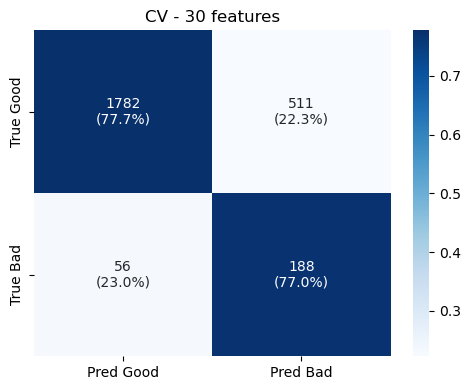


Features used: 29
Features removed: 4
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378']
Features removed:
['z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8529
Precision Bad CV: 0.2747
Recall Bad CV: 0.7869
F1 Bad CV: 0.4072

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.79      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.64      2537
weighted avg       0.90      0.78    

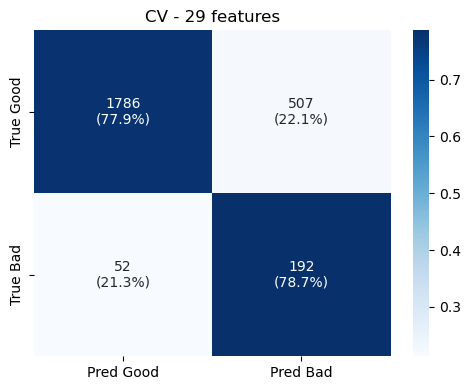


Features used: 28
Features removed: 5
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395']
Features removed:
['err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8519
Precision Bad CV: 0.2734
Recall Bad CV: 0.7787
F1 Bad CV: 0.4047

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.78      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78    

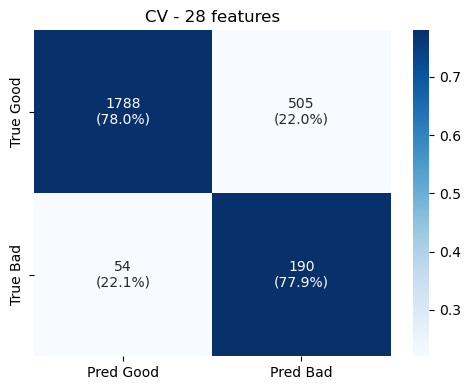


Features used: 27
Features removed: 6
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G']
Features removed:
['err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8544
Precision Bad CV: 0.2752
Recall Bad CV: 0.7951
F1 Bad CV: 0.4089

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.28      0.80      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.79      0.64      2537
weighted avg       0.91      0.78    

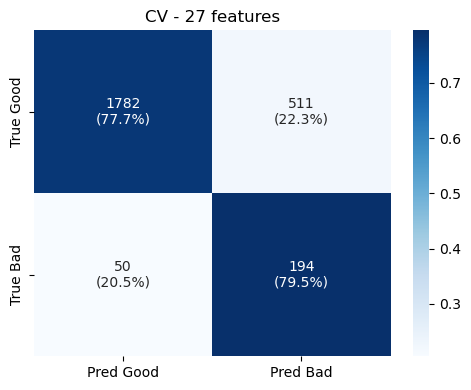


Features used: 26
Features removed: 7
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC']
Features removed:
['e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8547
Precision Bad CV: 0.2784
Recall Bad CV: 0.7828
F1 Bad CV: 0.4108

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.28      0.78      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.64      2537
weighted avg       0.90      0.78    

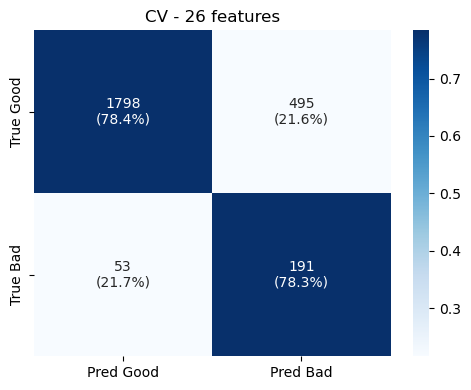


Features used: 25
Features removed: 8
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430']
Features removed:
['input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8550
Precision Bad CV: 0.2756
Recall Bad CV: 0.7828
F1 Bad CV: 0.4077

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.28      0.78      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.64      2537
weighted avg       0.90      0.78    

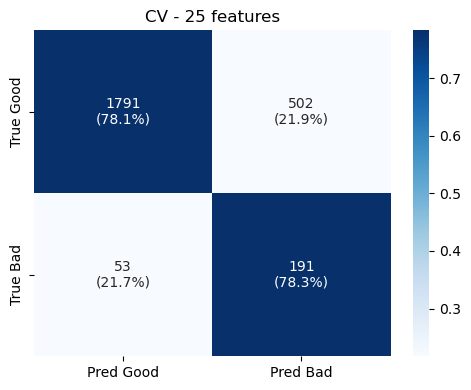


Features used: 24
Features removed: 9
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515']
Features removed:
['err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8539
Precision Bad CV: 0.2716
Recall Bad CV: 0.7746
F1 Bad CV: 0.4021

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.77      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78    

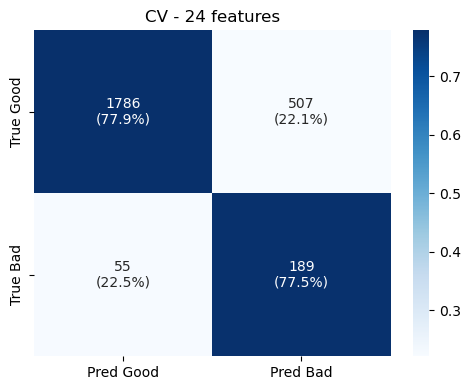


Features used: 23
Features removed: 10
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660']
Features removed:
['err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8544
Precision Bad CV: 0.2767
Recall Bad CV: 0.7869
F1 Bad CV: 0.4094

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.28      0.79      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.64      2537
weighted avg       0.90      0.78   

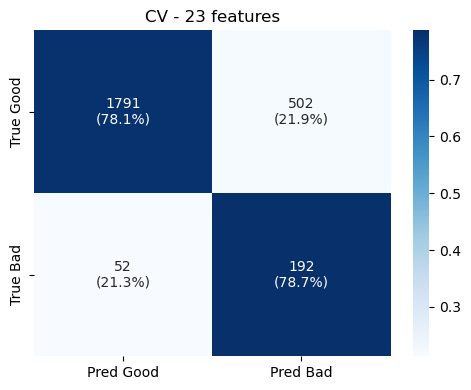


Features used: 22
Features removed: 11
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410']
Features removed:
['err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8534
Precision Bad CV: 0.2730
Recall Bad CV: 0.7664
F1 Bad CV: 0.4026

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.27      0.77      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78   

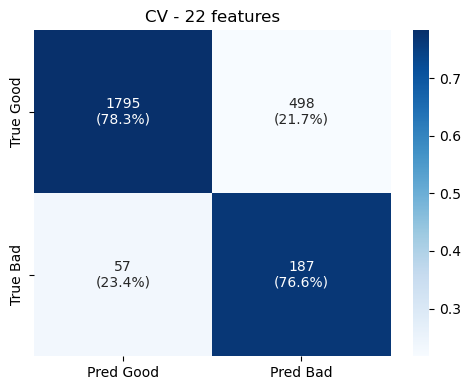


Features used: 21
Features removed: 12
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z']
Features removed:
['mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8546
Precision Bad CV: 0.2717
Recall Bad CV: 0.7582
F1 Bad CV: 0.4000

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.27      0.76      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78   

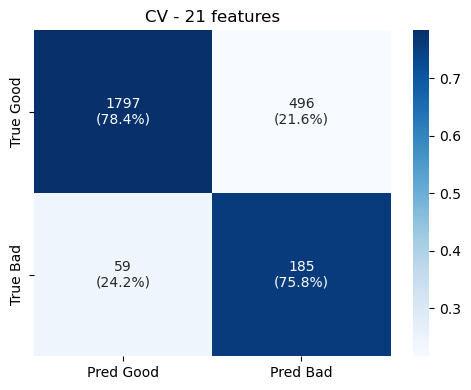


Features used: 20
Features removed: 13
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R']
Features removed:
['err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8565
Precision Bad CV: 0.2718
Recall Bad CV: 0.7664
F1 Bad CV: 0.4013

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.27      0.77      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78   

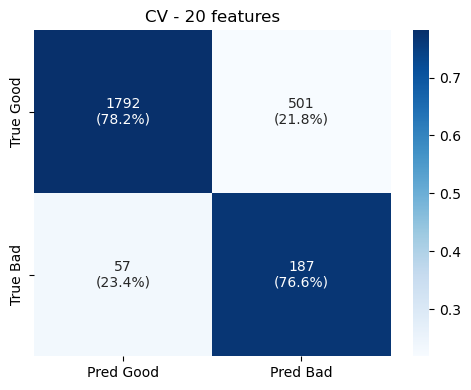


Features used: 19
Features removed: 14
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410']
Features removed:
['RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8564
Precision Bad CV: 0.2700
Recall Bad CV: 0.7746
F1 Bad CV: 0.4004

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.77      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78   

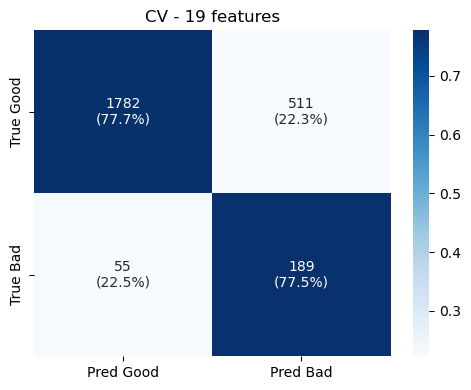


Features used: 18
Features removed: 15
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395']
Features removed:
['MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8545
Precision Bad CV: 0.2624
Recall Bad CV: 0.7582
F1 Bad CV: 0.3899

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.77      0.86      2293
         Bad       0.26      0.76      0.39       244

    accuracy                           0.77      2537
   macro avg       0.62      0.77      0.62      2537
weighted avg       0.90      0.77   

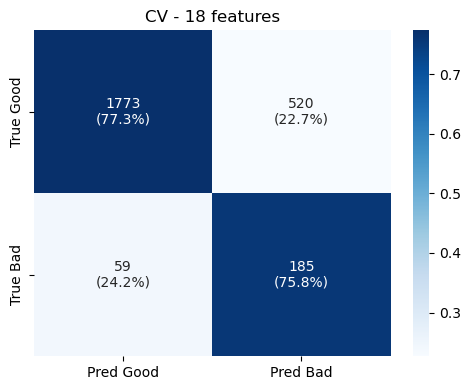


Features used: 17
Features removed: 16
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378']
Features removed:
['mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8577
Precision Bad CV: 0.2676
Recall Bad CV: 0.7623
F1 Bad CV: 0.3962

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.76      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78   

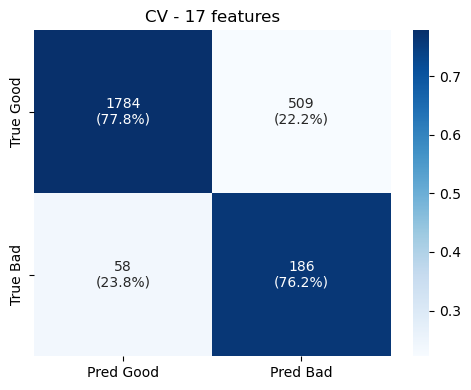


Features used: 16
Features removed: 17
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378']
Features removed:
['mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8579
Precision Bad CV: 0.2651
Recall Bad CV: 0.7541
F1 Bad CV: 0.3923

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.75      0.39       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78   

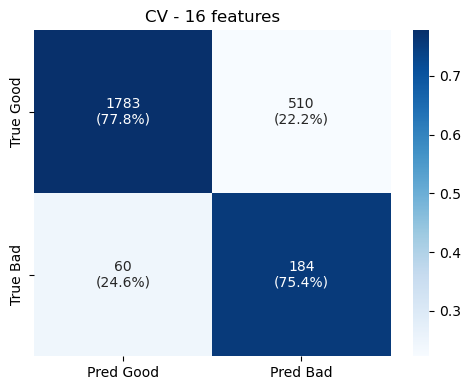


Features used: 15
Features removed: 18
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u']
Features removed:
['MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8564
Precision Bad CV: 0.2614
Recall Bad CV: 0.7500
F1 Bad CV: 0.3877

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.77      0.86      2293
         Bad       0.26      0.75      0.39       244

    accuracy                           0.77      2537
   macro avg       0.61      0.76      0.62      2537
weighted avg       0.90      0.77   

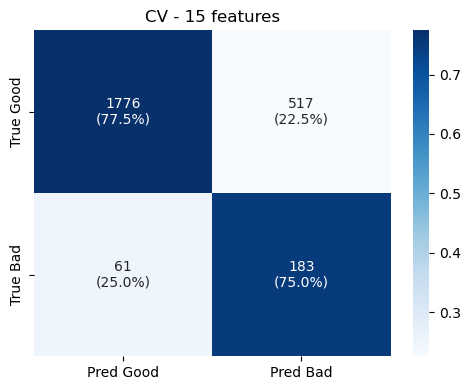


Features used: 14
Features removed: 19
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z']
Features removed:
['mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8581
Precision Bad CV: 0.2734
Recall Bad CV: 0.7787
F1 Bad CV: 0.4047

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.78      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78   

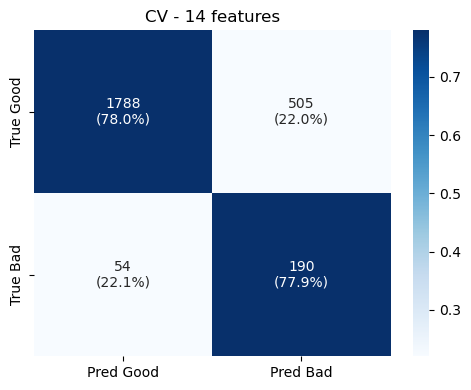


Features used: 13
Features removed: 20
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430']
Features removed:
['e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8477
Precision Bad CV: 0.2656
Recall Bad CV: 0.7828
F1 Bad CV: 0.3967

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.77      0.86      2293
         Bad       0.27      0.78      0.40       244

    accuracy                           0.77      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.77   

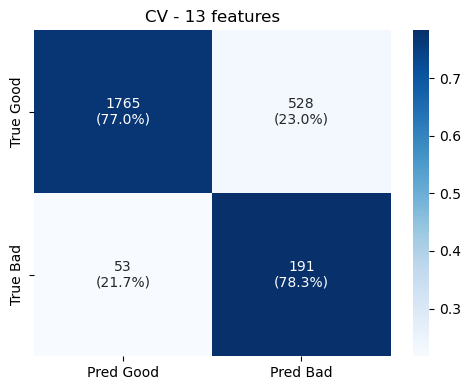


Features used: 12
Features removed: 21
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U']
Features removed:
['mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8500
Precision Bad CV: 0.2702
Recall Bad CV: 0.7828
F1 Bad CV: 0.4017

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.77      0.86      2293
         Bad       0.27      0.78      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78   

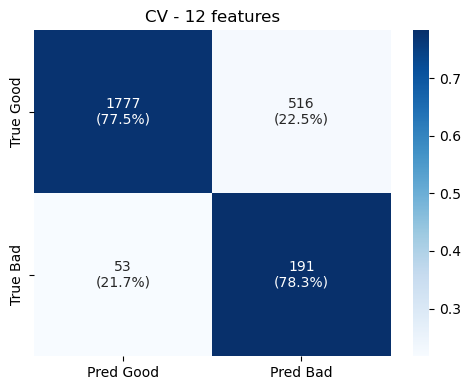


Features used: 11
Features removed: 22
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det']
Features removed:
['MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8503
Precision Bad CV: 0.2714
Recall Bad CV: 0.7910
F1 Bad CV: 0.4042

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.77      0.86      2293
         Bad       0.27      0.79      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78   

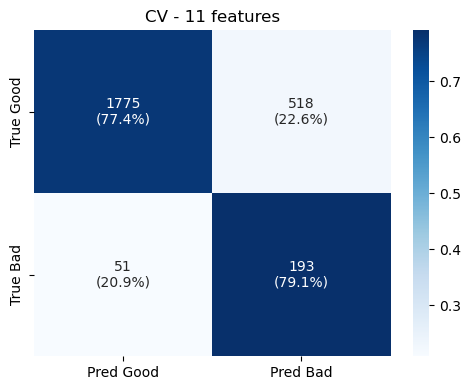


Features used: 10
Features removed: 23
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395']
Features removed:
['flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8487
Precision Bad CV: 0.2736
Recall Bad CV: 0.7828
F1 Bad CV: 0.4055

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.78      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78   

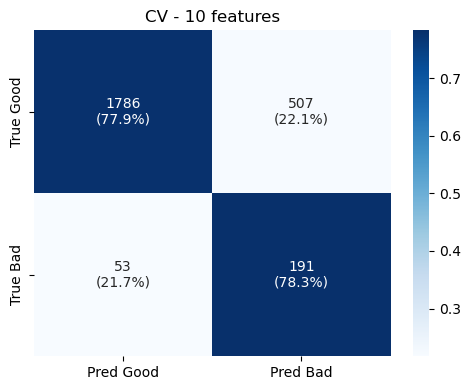


Features used: 9
Features removed: 24
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det']
Features removed:
['MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8523
Precision Bad CV: 0.2773
Recall Bad CV: 0.7910
F1 Bad CV: 0.4106

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.87      2293
         Bad       0.28      0.79      0.41       244

    accuracy                           0.78      2537
   macro avg       0.62      0.79      0.64      2537
weighted avg       0.91      0.78    

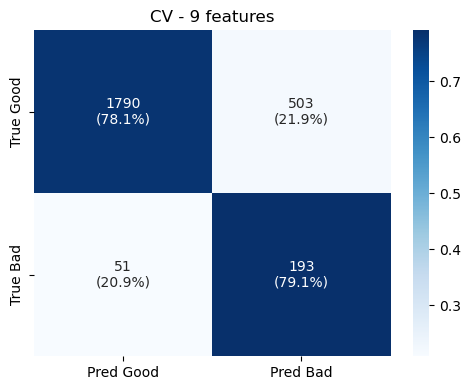


Features used: 8
Features removed: 25
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430']
Features removed:
['flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8510
Precision Bad CV: 0.2658
Recall Bad CV: 0.7582
F1 Bad CV: 0.3936

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.76      0.39       244

    accuracy                           0.78      2537
   macro avg       0.62      0.77      0.63      2537
weighted avg       0.90      0.78    

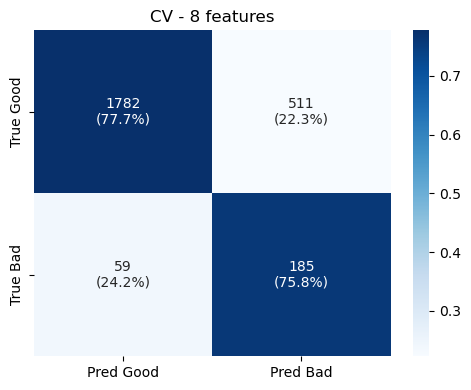


Features used: 7
Features removed: 26
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515']
Features removed:
['MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8516
Precision Bad CV: 0.2710
Recall Bad CV: 0.7787
F1 Bad CV: 0.4021

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.78      0.86      2293
         Bad       0.27      0.78      0.40       244

    accuracy                           0.78      2537
   macro avg       0.62      0.78      0.63      2537
weighted avg       0.90      0.78    

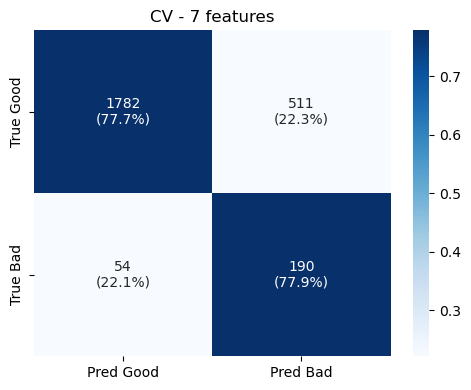


Features used: 6
Features removed: 27
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861']
Features removed:
['mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8453
Precision Bad CV: 0.2764
Recall Bad CV: 0.7623
F1 Bad CV: 0.4057

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.79      0.87      2293
         Bad       0.28      0.76      0.41       244

    accuracy                           0.79      2537
   macro avg       0.62      0.77      0.64      2537
weighted avg       0.90      0.79    

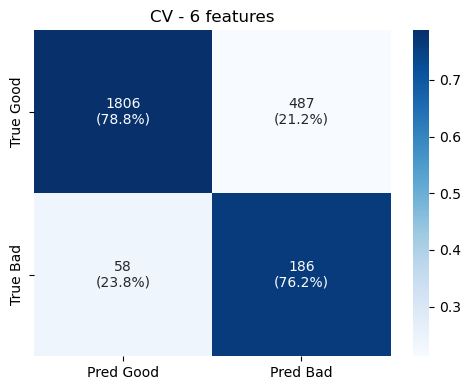


Features used: 5
Features removed: 28
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515']
Features removed:
['mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8251
Precision Bad CV: 0.2539
Recall Bad CV: 0.7336
F1 Bad CV: 0.3772

Classification Report:
              precision    recall  f1-score   support

        Good       0.96      0.77      0.86      2293
         Bad       0.25      0.73      0.38       244

    accuracy                           0.77      2537
   macro avg       0.61      0.75      0.62      2537
weighted avg       0.90      0.77    

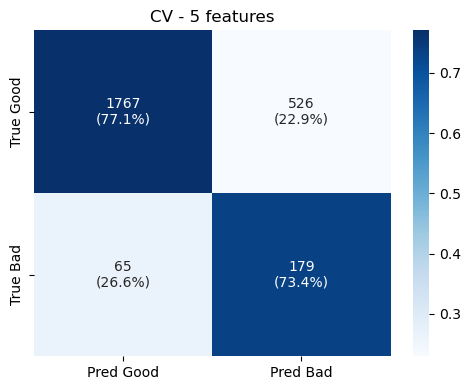


Features used: 4
Features removed: 29
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G']
Features removed:
['MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8210
Precision Bad CV: 0.2448
Recall Bad CV: 0.7295
F1 Bad CV: 0.3666

Classification Report:
              precision    recall  f1-score   support

        Good       0.96      0.76      0.85      2293
         Bad       0.24      0.73      0.37       244

    accuracy                           0.76      2537
   macro avg       0.60      0.75      0.61      2537
weighted avg       0.89      0.76    

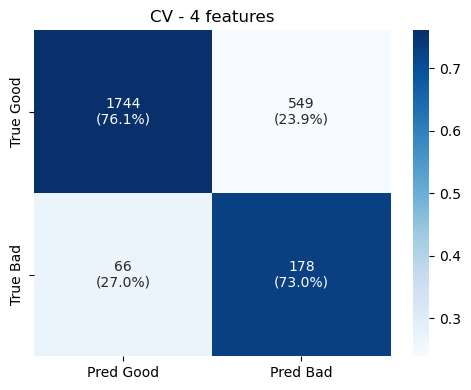


Features used: 3
Features removed: 30
Features current:
['CHI2NU', 'MAG_J0660', 'MAG_Z']
Features removed:
['MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8190
Precision Bad CV: 0.2392
Recall Bad CV: 0.7459
F1 Bad CV: 0.3622

Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.75      0.84      2293
         Bad       0.24      0.75      0.36       244

    accuracy                           0.75      2537
   macro avg       0.60      0.75      0.60      2537
weighted avg       0.90      0.75    

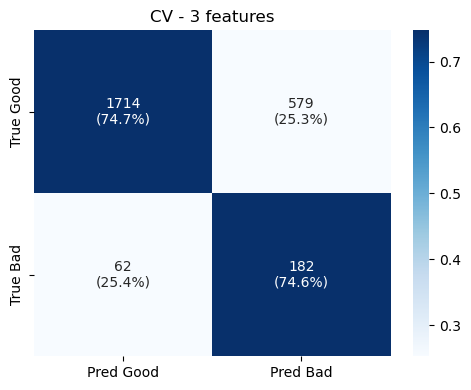


Features used: 2
Features removed: 31
Features current:
['CHI2NU', 'MAG_J0660']
Features removed:
['MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.8162
Precision Bad CV: 0.2314
Recall Bad CV: 0.7254
F1 Bad CV: 0.3508

Classification Report:
              precision    recall  f1-score   support

        Good       0.96      0.74      0.84      2293
         Bad       0.23      0.73      0.35       244

    accuracy                           0.74      2537
   macro avg       0.60      0.73      0.59      2537
weighted avg       0.89      0.74    

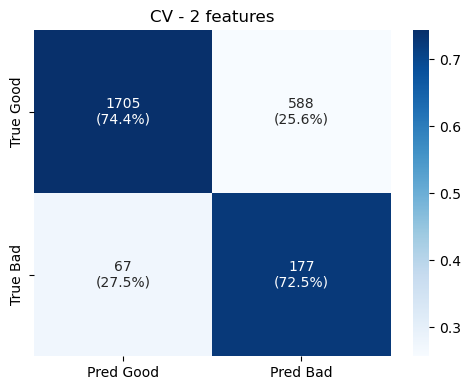


Features used: 1
Features removed: 32
Features current:
['CHI2NU']
Features removed:
['MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430', 'flux_radius_as_90_det', 'MAG_J0395', 'flux_radius_as_50_det', 'MAG_U', 'mag_auto_j0430', 'e_AR_Z', 'mag_auto_u', 'MAG_J0378', 'mag_auto_j0378', 'mag_auto_j0395', 'MAG_J0410', 'RE_R', 'err_mag_auto_z', 'mag_auto_j0410', 'err_mag_auto_j0660', 'err_mag_auto_j0515', 'err_mag_auto_j0430', 'input_DEC', 'e_PA_G', 'err_mag_auto_j0395', 'err_mag_auto_j0378', 'z', 'e_MAG_J0861', 'err_mag_auto_j0410', 'n_J0515']

AUC CV: 0.7492
Precision Bad CV: 0.1729
Recall Bad CV: 0.6639
F1 Bad CV: 0.2743

Classification Report:
              precision    recall  f1-score   support

        Good       0.95      0.66      0.78      2293
         Bad       0.17      0.66      0.27       244

    accuracy                           0.66      2537
   macro avg       0.56      0.66      0.53      2537
weighted avg       0.87      0.66    

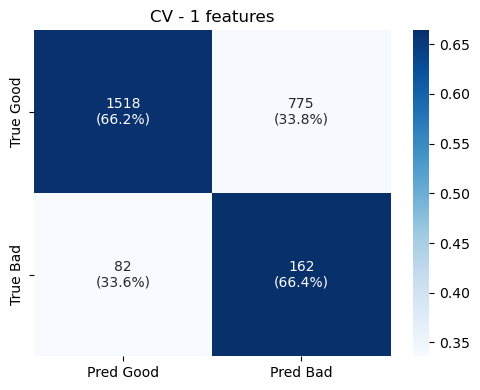


ABSTRACT
    n_features  features_removidas    auc_cv  precision_bad_cv  recall_bad_cv  \
0           33                   0  0.864379          0.277159       0.815574   
19          14                  19  0.858136          0.273381       0.778689   
17          16                  17  0.857873          0.265130       0.754098   
16          17                  16  0.857664          0.267626       0.762295   
1           32                   1  0.857411          0.276446       0.803279   
2           31                   2  0.856588          0.274510       0.803279   
13          20                  13  0.856536          0.271802       0.766393   
18          15                  18  0.856436          0.261429       0.750000   
14          19                  14  0.856416          0.270000       0.774590   
8           25                   8  0.854985          0.275613       0.782787   
7           26                   7  0.854691          0.278426       0.782787   
12          21    

In [7]:
#Dataset

df_model = df[features_sel + ["label"]].copy()

X = df_model[features_sel]
y = df_model["label"].values


#Functions

def make_rf_pipeline(seed=SEED):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", BalancedRandomForestClassifier(
            n_estimators=1000,
            random_state=seed,
            n_jobs=-1,
            min_samples_leaf=2
        ))
    ])


def plot_cm(cm, title):
    row_sums = cm.sum(axis=1, keepdims=True).astype(float)
    row_sums[row_sums == 0] = 1

    cm_pct = cm / row_sums

    ann = [
        [f"{cm[i, j]}\n({cm_pct[i, j] * 100:.1f}%)" for j in range(2)]
        for i in range(2)
    ]

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm_pct,
        annot=ann,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred Good", "Pred Bad"],
        yticklabels=["True Good", "True Bad"]
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


#Cross validation and feature remove

features_ordered = list(features_sel)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

resultados_brf = []

for i in range(len(features_ordered)):

    n_remove = i
    n_keep = len(features_ordered) - n_remove

    if n_keep <= 0:
        break

    current_features = features_ordered[:n_keep]
    removed_features = features_ordered[n_keep:]

    print("\n====================================================")
    print(f"Features used: {n_keep}")
    print(f"Features removed: {n_remove}")
    print("Features current:")
    print(current_features)

    if len(removed_features) > 0:
        print("Features removed:")
        print(removed_features)

    rf = make_rf_pipeline(seed=SEED)

    prob_cv = cross_val_predict(
        rf,
        X[current_features],
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    pred_cv = (prob_cv >= 0.5).astype(int)

    auc_cv = roc_auc_score(y, prob_cv)

    precision_bad_cv = precision_score(
        y,
        pred_cv,
        pos_label=1,
        zero_division=0
    )

    recall_bad_cv = recall_score(
        y,
        pred_cv,
        pos_label=1,
        zero_division=0
    )

    f1_bad_cv = f1_score(
        y,
        pred_cv,
        pos_label=1,
        zero_division=0
    )

    print(f"\nAUC CV: {auc_cv:.4f}")
    print(f"Precision Bad CV: {precision_bad_cv:.4f}")
    print(f"Recall Bad CV: {recall_bad_cv:.4f}")
    print(f"F1 Bad CV: {f1_bad_cv:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y,
        pred_cv,
        target_names=["Good", "Bad"],
        zero_division=0
    ))

    cm_cv = confusion_matrix(y, pred_cv)
    plot_cm(cm_cv, f"CV - {n_keep} features")

    row = {
        "n_features": n_keep,
        "features_removidas": n_remove,
        "auc_cv": auc_cv,
        "precision_bad_cv": precision_bad_cv,
        "recall_bad_cv": recall_bad_cv,
        "f1_bad_cv": f1_bad_cv,
        "features_usadas": current_features,
        "features_removidas_lista": removed_features
    }

    resultados_brf.append(row)


df_resultados_brf = pd.DataFrame(resultados_brf)

print("\n====================================================")
print("ABSTRACT")

print(df_resultados_brf[[
    "n_features",
    "features_removidas",
    "auc_cv",
    "precision_bad_cv",
    "recall_bad_cv",
    "f1_bad_cv"
]].sort_values("auc_cv", ascending=False))


melhor_idx_auc = df_resultados_brf["auc_cv"].idxmax()
melhor_resultado_auc = df_resultados_brf.loc[melhor_idx_auc]

print("\n====================================================")
print("BEST RESULT BY AUC")

print(f"Number of features: {melhor_resultado_auc['n_features']}")
print(f"Features removed: {melhor_resultado_auc['features_removidas']}")

print(f"\nAUC CV: {melhor_resultado_auc['auc_cv']:.4f}")
print(f"Precision Bad CV: {melhor_resultado_auc['precision_bad_cv']:.4f}")
print(f"Recall Bad CV: {melhor_resultado_auc['recall_bad_cv']:.4f}")
print(f"F1 Bad CV: {melhor_resultado_auc['f1_bad_cv']:.4f}")

print("\nFeatures chosen:")
print(melhor_resultado_auc["features_usadas"])

print("\nFeatures removed:")
print(melhor_resultado_auc["features_removidas_lista"])


## Keep in the same range (quantile 0.01 - 0.99)


Features available:
['CHI2NU', 'MAG_J0660', 'MAG_Z', 'MAG_G', 'MAG_J0515', 'mag_auto_j0861', 'mag_auto_j0515', 'MAG_J0430']

QRange filter report:
       feature  q01_train  q99_train  dr6_total  inside_qrange  removed_by_feature  removed_percent
mag_auto_j0861  13.442951  18.530098       5539           5199                 340         6.138292
         MAG_Z  12.588372  18.590696       5539           5327                 212         3.827406
     MAG_J0660  13.268056  18.840368       5539           5344                 195         3.520491
mag_auto_j0515  14.544476  19.358799       5539           5369                 170         3.069146
     MAG_J0515  13.920628  19.278052       5539           5411                 128         2.310886
         MAG_G  14.217868  19.465668       5539           5424                 115         2.076187
     MAG_J0430  14.904752  20.963476       5539           5425                 114         2.058133
        CHI2NU   1.134000 161.633600       5539     

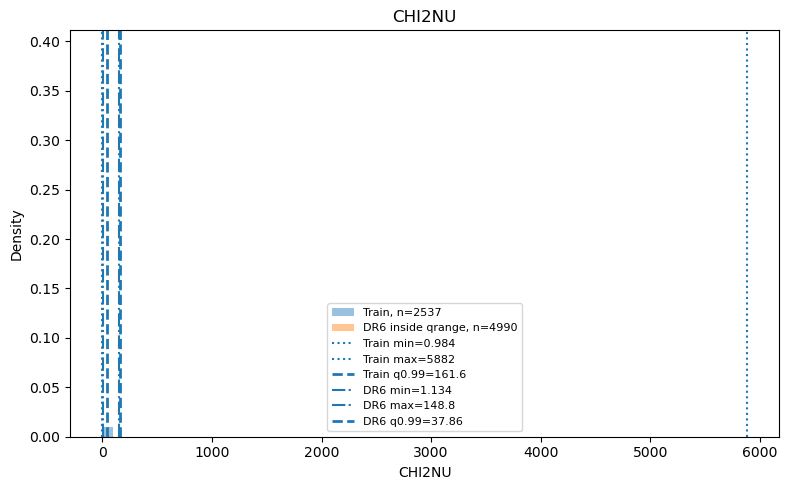

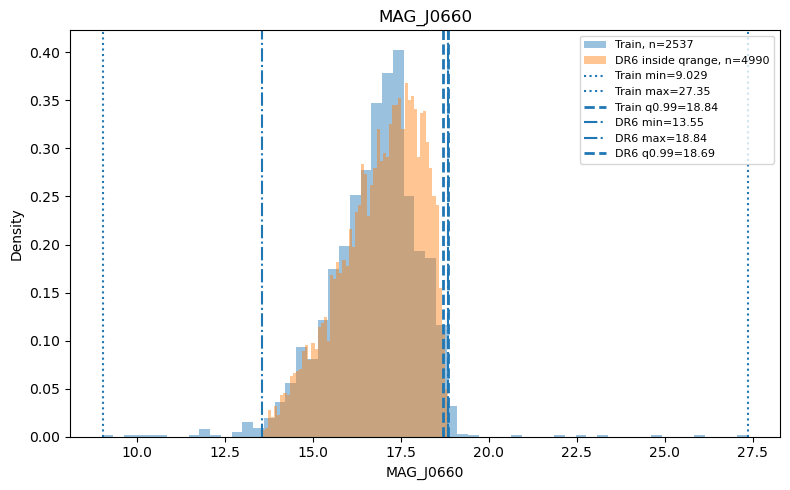

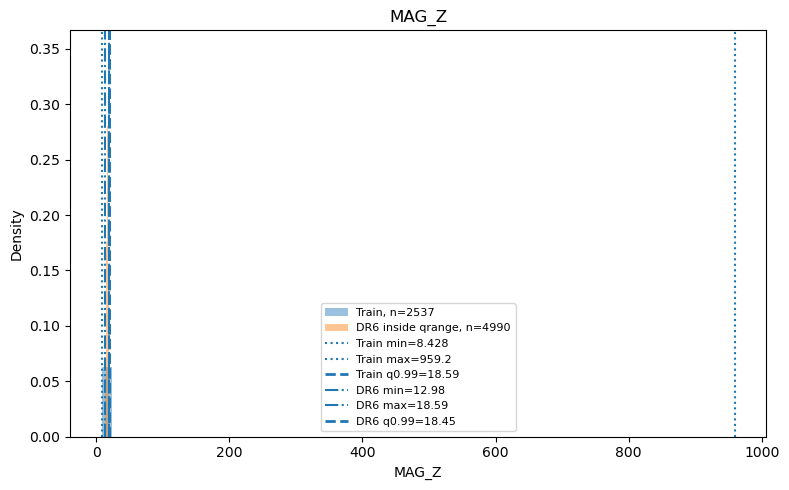

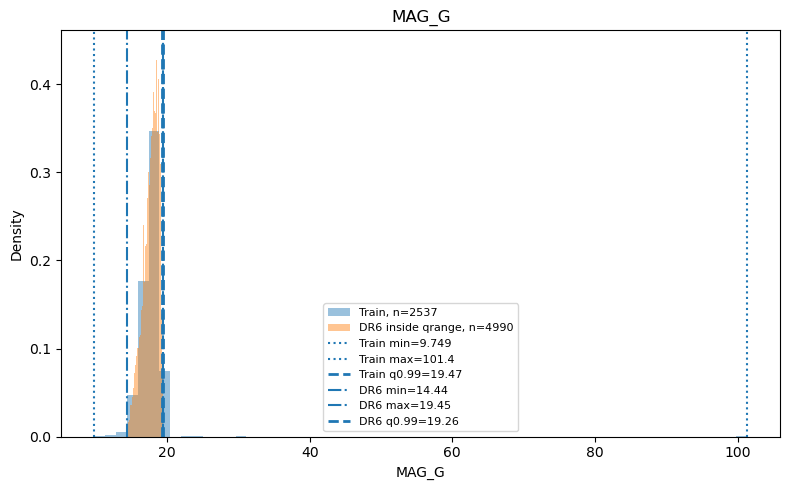

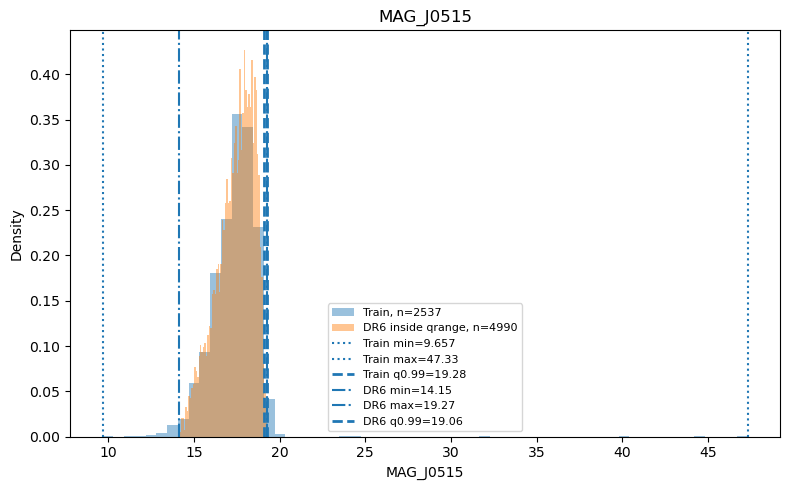

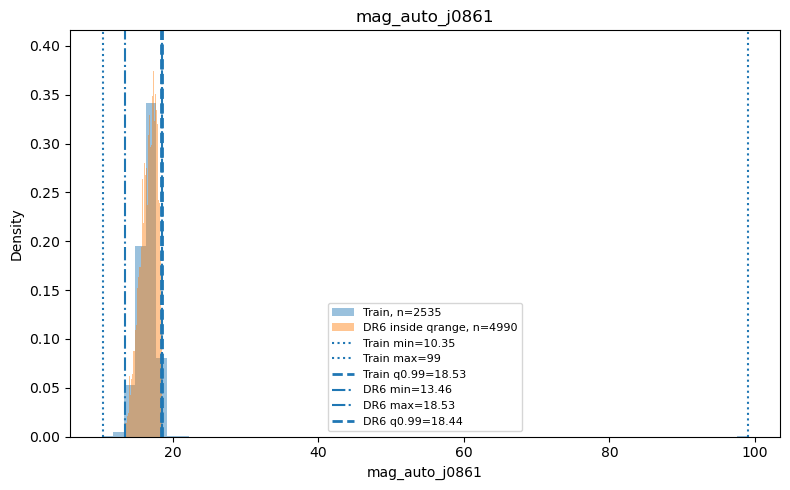

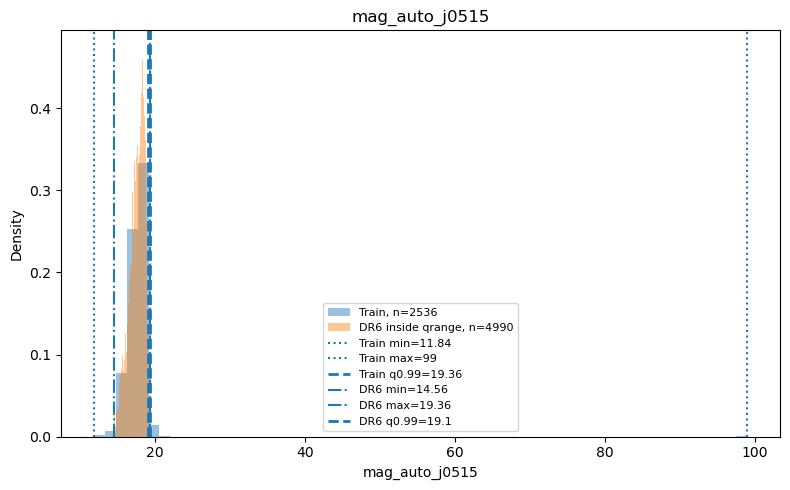

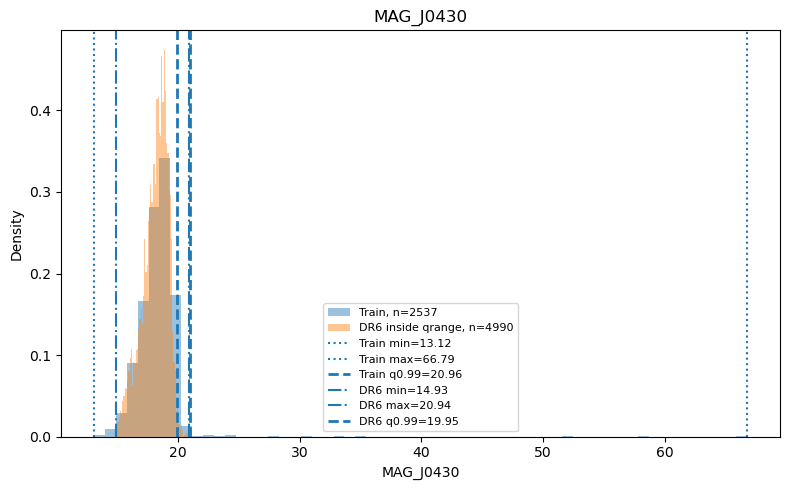

In [8]:
#Path
grupo_dr6_path = r"D:/Work/splus-transfer-learning/grupos_Dr6_dr6_matches_morphopLUS.csv"

#Features
features_8 = [
    "CHI2NU",
    "MAG_J0660",
    "MAG_Z",
    "MAG_G",
    "MAG_J0515",
    "mag_auto_j0861",
    "mag_auto_j0515",
    "MAG_J0430"
]

df_grupo_dr6 = pd.read_csv(grupo_dr6_path, low_memory=False)
df_grupo_dr6.columns = df_grupo_dr6.columns.str.strip()

df_train_analysis = df.copy()
df_new_analysis = df_grupo_dr6.copy()


#Convert to numeric with more care
def convert_numeric(df):
    df = df.copy()

    for col in df.columns:
        s = df[col].astype(str)
        s = s.str.replace("*", "", regex=False)
        s = s.str.replace(",", ".", regex=False)
        s = s.str.strip()

        s = s.replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan,
            "NaN": np.nan
        })

        num = pd.to_numeric(s, errors="coerce")

        if num.notna().sum() > 0:
            df[col] = num

    return df


df_train_analysis = convert_numeric(df_train_analysis)
df_new_analysis = convert_numeric(df_new_analysis)

def finite_series(df, col):
    if col not in df.columns:
        return pd.Series(dtype=float)

    s = pd.to_numeric(df[col], errors="coerce")
    return s[np.isfinite(s)]


#Features equal in both datasets
features_available = [
    col for col in features_8
    if col in df_train_analysis.columns and col in df_new_analysis.columns
]

print("\nFeatures available:")
print(features_available)


#Filter q01 and q99 of the training set
df_dr6_qrange = df_new_analysis.copy()

mask = pd.Series(True, index=df_dr6_qrange.index)

range_rows = []

for col in features_available:
    train_s = finite_series(df_train_analysis, col)
    dr6_s = pd.to_numeric(df_dr6_qrange[col], errors="coerce")

    if len(train_s) == 0:
        continue

    q_low = np.quantile(train_s, 0.01)
    q_high = np.quantile(train_s, 0.99)

    valid = np.isfinite(dr6_s) & (dr6_s >= q_low) & (dr6_s <= q_high)

    range_rows.append({
        "feature": col,
        "q01_train": q_low,
        "q99_train": q_high,
        "dr6_total": len(df_dr6_qrange),
        "inside_qrange": int(valid.sum()),
        "removed_by_feature": int((~valid).sum()),
        "removed_percent": 100 * int((~valid).sum()) / len(df_dr6_qrange)
    })

    mask &= valid


df_qrange_report = pd.DataFrame(range_rows)

print("\nQRange filter report:")
print(
    df_qrange_report
    .sort_values("removed_by_feature", ascending=False)
    .to_string(index=False)
)

df_dr6_qrange = df_dr6_qrange.loc[mask].copy()

print(f"\nBefore: {len(df_new_analysis)}")
print(f"After: {len(df_dr6_qrange)}")
print(f"Removed: {len(df_new_analysis) - len(df_dr6_qrange)}")
print(f"%: {(1 - len(df_dr6_qrange) / len(df_new_analysis)) * 100:.2f}%")


# Plot dos histogramas após o filtro
def plot_hist_after_filter(train_df, dr6_filtered_df, col, bins=60, q=0.99):
    train_s = finite_series(train_df, col)
    new_s = finite_series(dr6_filtered_df, col)

    if len(train_s) == 0 or len(new_s) == 0:
        print(f"[WARNING] Sem dados válidos para {col}")
        return

    train_q = np.quantile(train_s, q)
    new_q = np.quantile(new_s, q)

    plt.figure(figsize=(8, 5))

    plt.hist(
        train_s,
        bins=bins,
        alpha=0.45,
        density=True,
        label=f"Train, n={len(train_s)}"
    )

    plt.hist(
        new_s,
        bins=bins,
        alpha=0.45,
        density=True,
        label=f"DR6 inside qrange, n={len(new_s)}"
    )

    # Linhas do treino
    plt.axvline(
        train_s.min(),
        linestyle=":",
        linewidth=1.5,
        label=f"Train min={train_s.min():.4g}"
    )

    plt.axvline(
        train_s.max(),
        linestyle=":",
        linewidth=1.5,
        label=f"Train max={train_s.max():.4g}"
    )

    plt.axvline(
        train_q,
        linestyle="--",
        linewidth=2,
        label=f"Train q{q:.2f}={train_q:.4g}"
    )

    # Linhas do DR6 filtrado
    plt.axvline(
        new_s.min(),
        linestyle="-.",
        linewidth=1.5,
        label=f"DR6 min={new_s.min():.4g}"
    )

    plt.axvline(
        new_s.max(),
        linestyle="-.",
        linewidth=1.5,
        label=f"DR6 max={new_s.max():.4g}"
    )

    plt.axvline(
        new_q,
        linestyle="--",
        linewidth=2,
        label=f"DR6 q{q:.2f}={new_q:.4g}"
    )

    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(col)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


for col in features_available:
    plot_hist_after_filter(
        df_train_analysis,
        df_dr6_qrange,
        col,
        bins=60,
        q=0.99
    )